In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('fivethirtyeight')

In [2]:
reviews_df = pd.read_csv('C:/Develop/深圳42/data/reviews.csv')
reviews_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5077 entries, 0 to 5076
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   stars         5077 non-null   object
 1   date          5077 non-null   object
 2   type          5077 non-null   object
 3   short_d       5075 non-null   object
 4   content       5076 non-null   object
 5   product_name  5077 non-null   object
 6   name          5061 non-null   object
dtypes: object(7)
memory usage: 277.8+ KB


In [3]:
reviews_df.head()

,stars,date,type,short_d,content,product_name,name
0,2.0 out of 5 stars,"Reviewed in the United States on June 24, 2020",Rainbow String,For children,"This is for children, not adults. I cannot use...",everjoys-Soprano,Kathy
1,1.0 out of 5 stars,"Reviewed in the United States on June 24, 2020",Rainbow String,Returned.,Impossible to tune.,everjoys-Soprano,Pam Palumbo
2,4.0 out of 5 stars,"Reviewed in the United States on June 22, 2020",Mahogany,Nice,Very nice product! The ukulele is very light a...,everjoys-Soprano,andy
3,5.0 out of 5 stars,"Reviewed in the United States on June 20, 2020",Rainbow String,Buy it,It was a great guitar for beginning guitar pla...,everjoys-Soprano,Donna
4,2.0 out of 5 stars,"Reviewed in the United States on June 18, 2020",Rainbow String,Wouldn't hold a tune,"It is a cute little ukulele, but is poor quali...",everjoys-Soprano,Amazon Customer


In [4]:
reviews_df['stars'].value_counts()

5.0 out of 5 stars    3803
4.0 out of 5 stars     606
1.0 out of 5 stars     261
3.0 out of 5 stars     246
2.0 out of 5 stars     161
Name: stars, dtype: int64

In [6]:
reviews_df['product_name'].value_counts()

donner              1402
everjoys-Soprano    1364
ranch               1204
kala                1107
Name: product_name, dtype: int64

In [7]:
reviews_df = reviews_df.dropna()

In [9]:
# 从评星的文本中提取出了1~5的分数
reviews_df['stars'] = reviews_df['stars'].apply(lambda x:float(x.replace(' out of 5 stars','')))

In [11]:
# 区分好评中评差评  1,2 差  3 中 4,5 好
reviews_df['reviews_cate'] = pd.cut(reviews_df['stars'], bins=[0,2,3,5], labels=['差评','中评','好评'])

In [16]:
reviews_df['reviews_cate'].value_counts()

好评    4393
差评     421
中评     245
Name: reviews_cate, dtype: int64

In [19]:
def get_date(x):
    # Reviewed in the United States on June 24, 2020
    # 使用 'on '拆分  第一个元素就是 月 日, 年 
    x = x.split('on ')[1]
    #
    x = x.split(', ') # June 24, 2020 ['June 24','2020']
    y=x[1] # 
    x=x[0].split(' ')
    m,d = x[0],x[1]
    if m=='January' or m=='Jan':
        on_date='01-'+d+'-'+y
    elif m=='February' or m=='Feb':
        on_date='02-'+d+'-'+y
    elif m=='March' or m=='Mar':
        on_date='03-'+d+'-'+y
    elif m=='April' or m=='Apr':
        on_date='04-'+d+'-'+y
    elif m=='May':
        on_date='05-'+d+'-'+y
    elif m=='June' or m=='Jun':
        on_date='06-'+d+'-'+y
    elif m=='July' or m=='Jul':
        on_date='07-'+d+'-'+y
    elif m=='August' or m=='Aug':
        on_date='08-'+d+'-'+y
    elif m=='September' or m=='Sep':
        on_date='09-'+d+'-'+y
    elif m=='October' or m=='Oct':
        on_date='10-'+d+'-'+y
    elif m=='November' or m=='Nov':
        on_date='11-'+d+'-'+y
    elif m=='December' or m=='Dec':
        on_date='12-'+d+'-'+y 
    return on_date

reviews_df['date'] = reviews_df['date'].apply(get_date)


In [20]:
reviews_df['date'] = pd.to_datetime(reviews_df['date'])

## 结构化数据的分析

<Axes: xlabel='product_name', ylabel='count'>

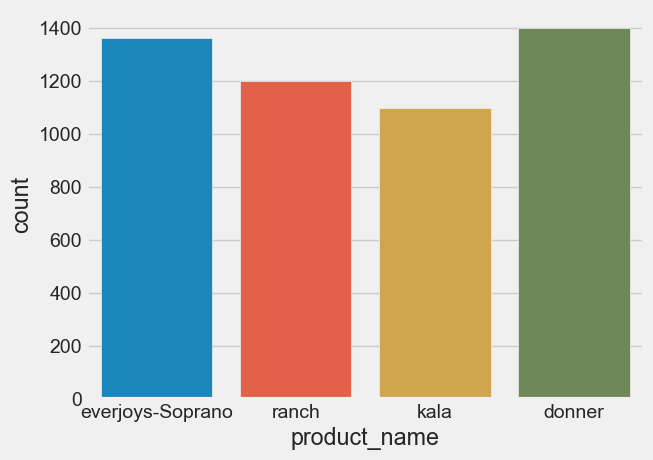

In [21]:
sns.countplot(x='product_name', data=reviews_df)

In [58]:
# reviews_df['y_m']=reviews_df['date'].dt.year.astype(str)+'-'+f"{reviews_df['date'].dt.month}:02d"

In [63]:
# 格式化字符串
reviews_df['month'] = reviews_df['date'].dt.month.apply(lambda x:f"{x:02d}")

In [65]:
reviews_df['y_m']=reviews_df['date'].dt.year.astype(str)+'-'+reviews_df['month']

In [38]:
reviews_df

,stars,date,type,short_d,content,product_name,name,reviews_cate,y_m
0,2.0,2020-06-24,Rainbow String,For children,"This is for children, not adults. I cannot use...",everjoys-Soprano,Kathy,差评,2020-6
1,1.0,2020-06-24,Rainbow String,Returned.,Impossible to tune.,everjoys-Soprano,Pam Palumbo,差评,2020-6
2,4.0,2020-06-22,Mahogany,Nice,Very nice product! The ukulele is very light a...,everjoys-Soprano,andy,好评,2020-6
3,5.0,2020-06-20,Rainbow String,Buy it,It was a great guitar for beginning guitar pla...,everjoys-Soprano,Donna,好评,2020-6
4,2.0,2020-06-18,Rainbow String,Wouldn't hold a tune,"It is a cute little ukulele, but is poor quali...",everjoys-Soprano,Amazon Customer,差评,2020-6
...,...,...,...,...,...,...,...,...,...
5072,1.0,2017-12-01,Tenor,... bridge is to low causing the strings to ra...,The product arrived with the Fretboard cracked...,donner,Addm,差评,2017-12
5073,5.0,2017-12-01,Tenor,Good Value,Good finishing. Wish the bag's zipper went al...,donner,John,好评,2017-12
5074,5.0,2017-11-30,Soprano,Five Stars,Very happy with the quality of it.,donner,Salvador Ruiz,好评,2017-11
5075,5.0,2017-11-30,Concert,Five Stars,I like the looks of the ukulele and the tone.,donner,Amazon Customer,好评,2017-11


<Axes: xlabel='reviews_cate', ylabel='count'>

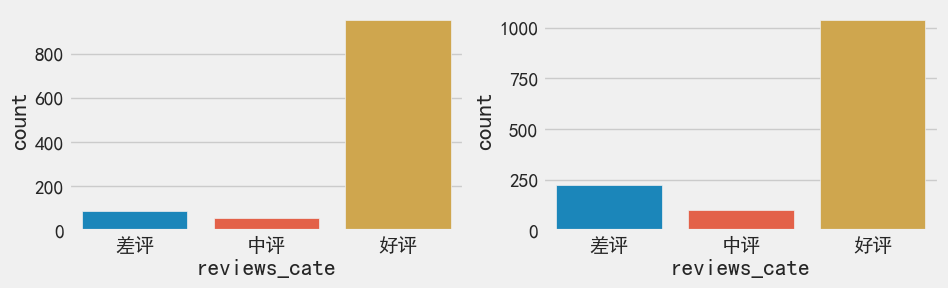

In [43]:
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.figure(figsize=(10,6))
plt.subplot(2,2,1)
kala_df = reviews_df[reviews_df['product_name']=='kala']
sns.countplot(data = kala_df,x='reviews_cate')
plt.subplot(2,2,2)
everjoys_df = reviews_df[reviews_df['product_name']=='everjoys-Soprano']
sns.countplot(data = everjoys_df,x='reviews_cate')
plt.subplot(2,2,3)
everjoys_df = reviews_df[reviews_df['product_name']=='everjoys-Soprano']
sns.countplot(data = everjoys_df,x='reviews_cate')

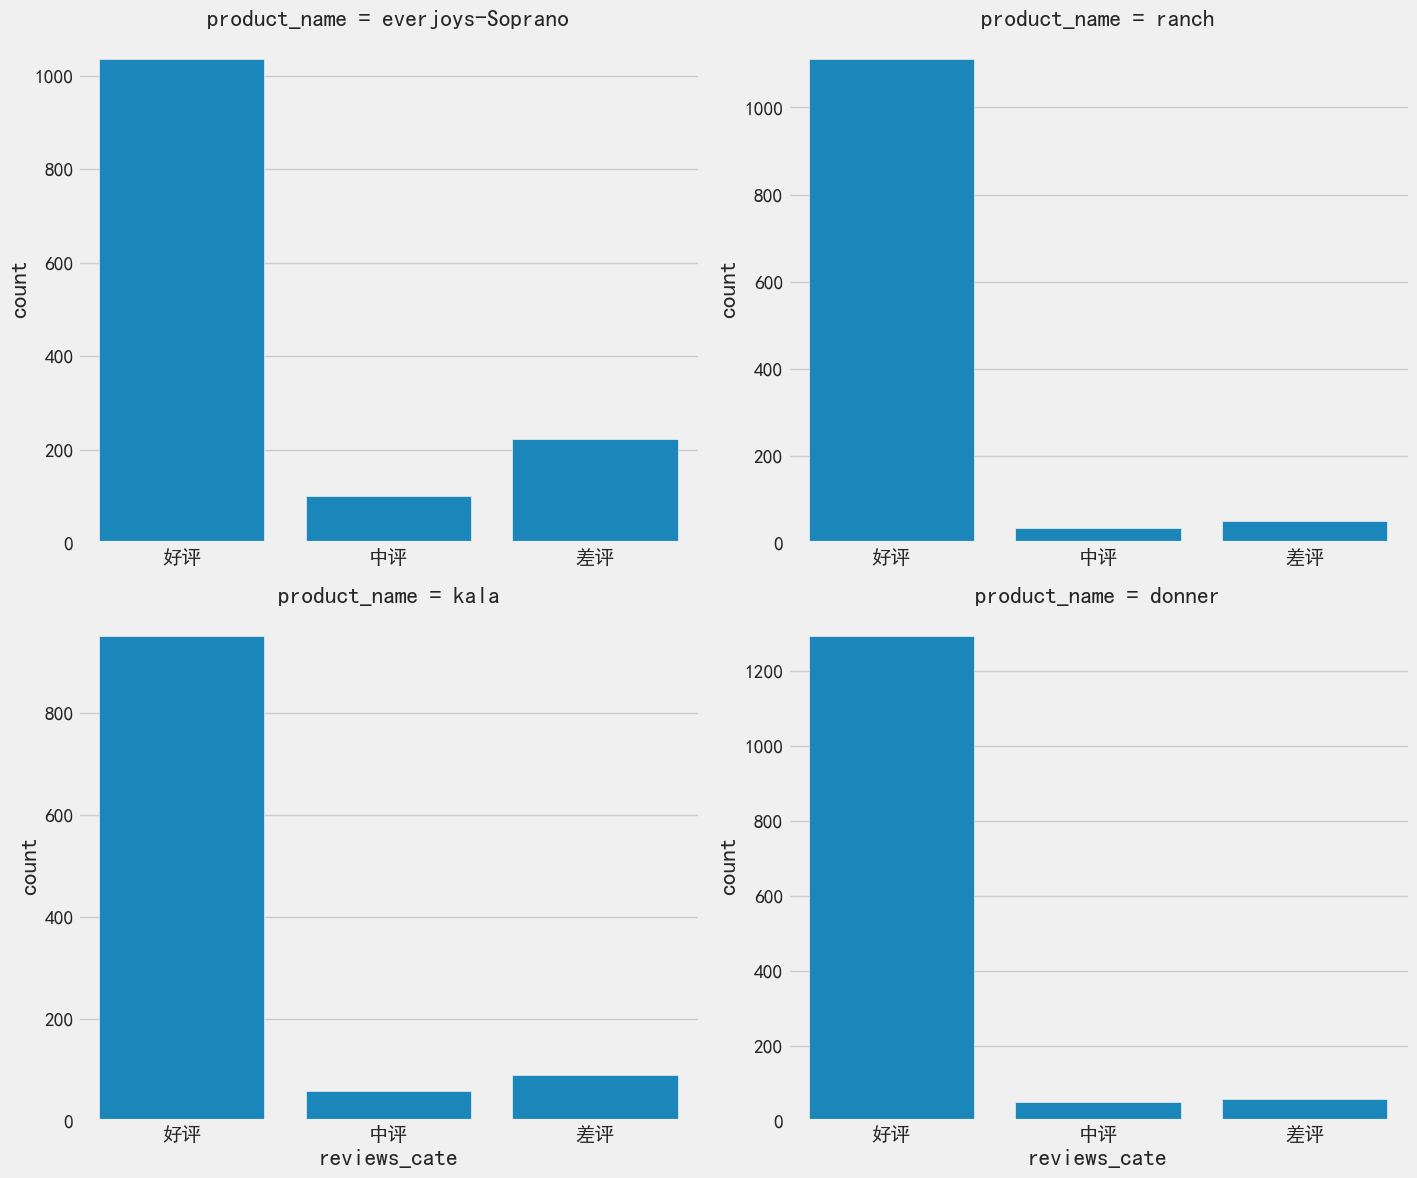

In [52]:
#  FacetGrid 使用场景, 当从数据中, 指定某一列, 根据这一列的取值选取数据的子集, 每一份子集绘制相同的图形, 这个时候就可以使用
# FacetGrid, data 数据  col 使用哪一列来获取数据的子集, col_wrap 画的子图有几列, 指定了列数之后, 行数自动计算
# sharex sharey 子图之间是否共享x,y轴坐标, 默认是共享的
#  height 指定绘图区域的高度, aspect 宽度高度的比例 通过这两个参数可以调整绘图区域的大小
# FacetGrid 会返回一个对象
g = sns.FacetGrid(data = reviews_df,col='product_name',col_wrap=2,sharex=False,sharey=False,height = 6,aspect=1.2)
# 通过FacetGrid返回的对象, 调用map方法, 传入要是用的绘图方法对象, 后面传入这个绘图方法对象要使用的参数, data数据不需要传的
g.map(sns.countplot,'reviews_cate',order=['好评','中评','差评'])

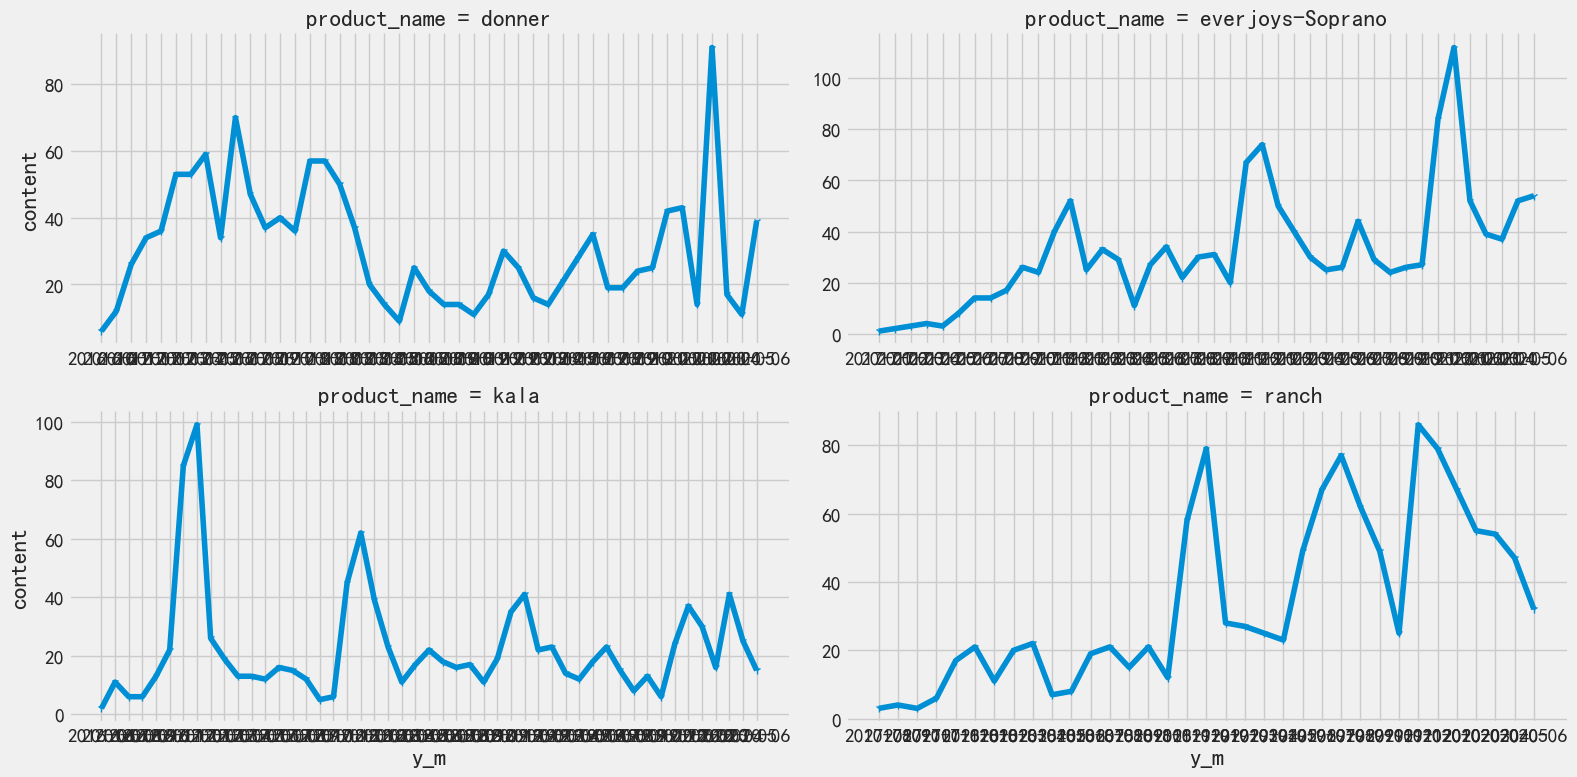

In [71]:
df_content = reviews_df.groupby(['product_name','y_m'])['content'].count().reset_index()
g = sns.FacetGrid(data=df_content,col='product_name',col_wrap=2,sharex=False,sharey=False,height=4,aspect=2)
g.map(plt.plot,'y_m','content',marker='1')

In [73]:
df_content['y_m'] = pd.to_datetime(df_content['y_m'])

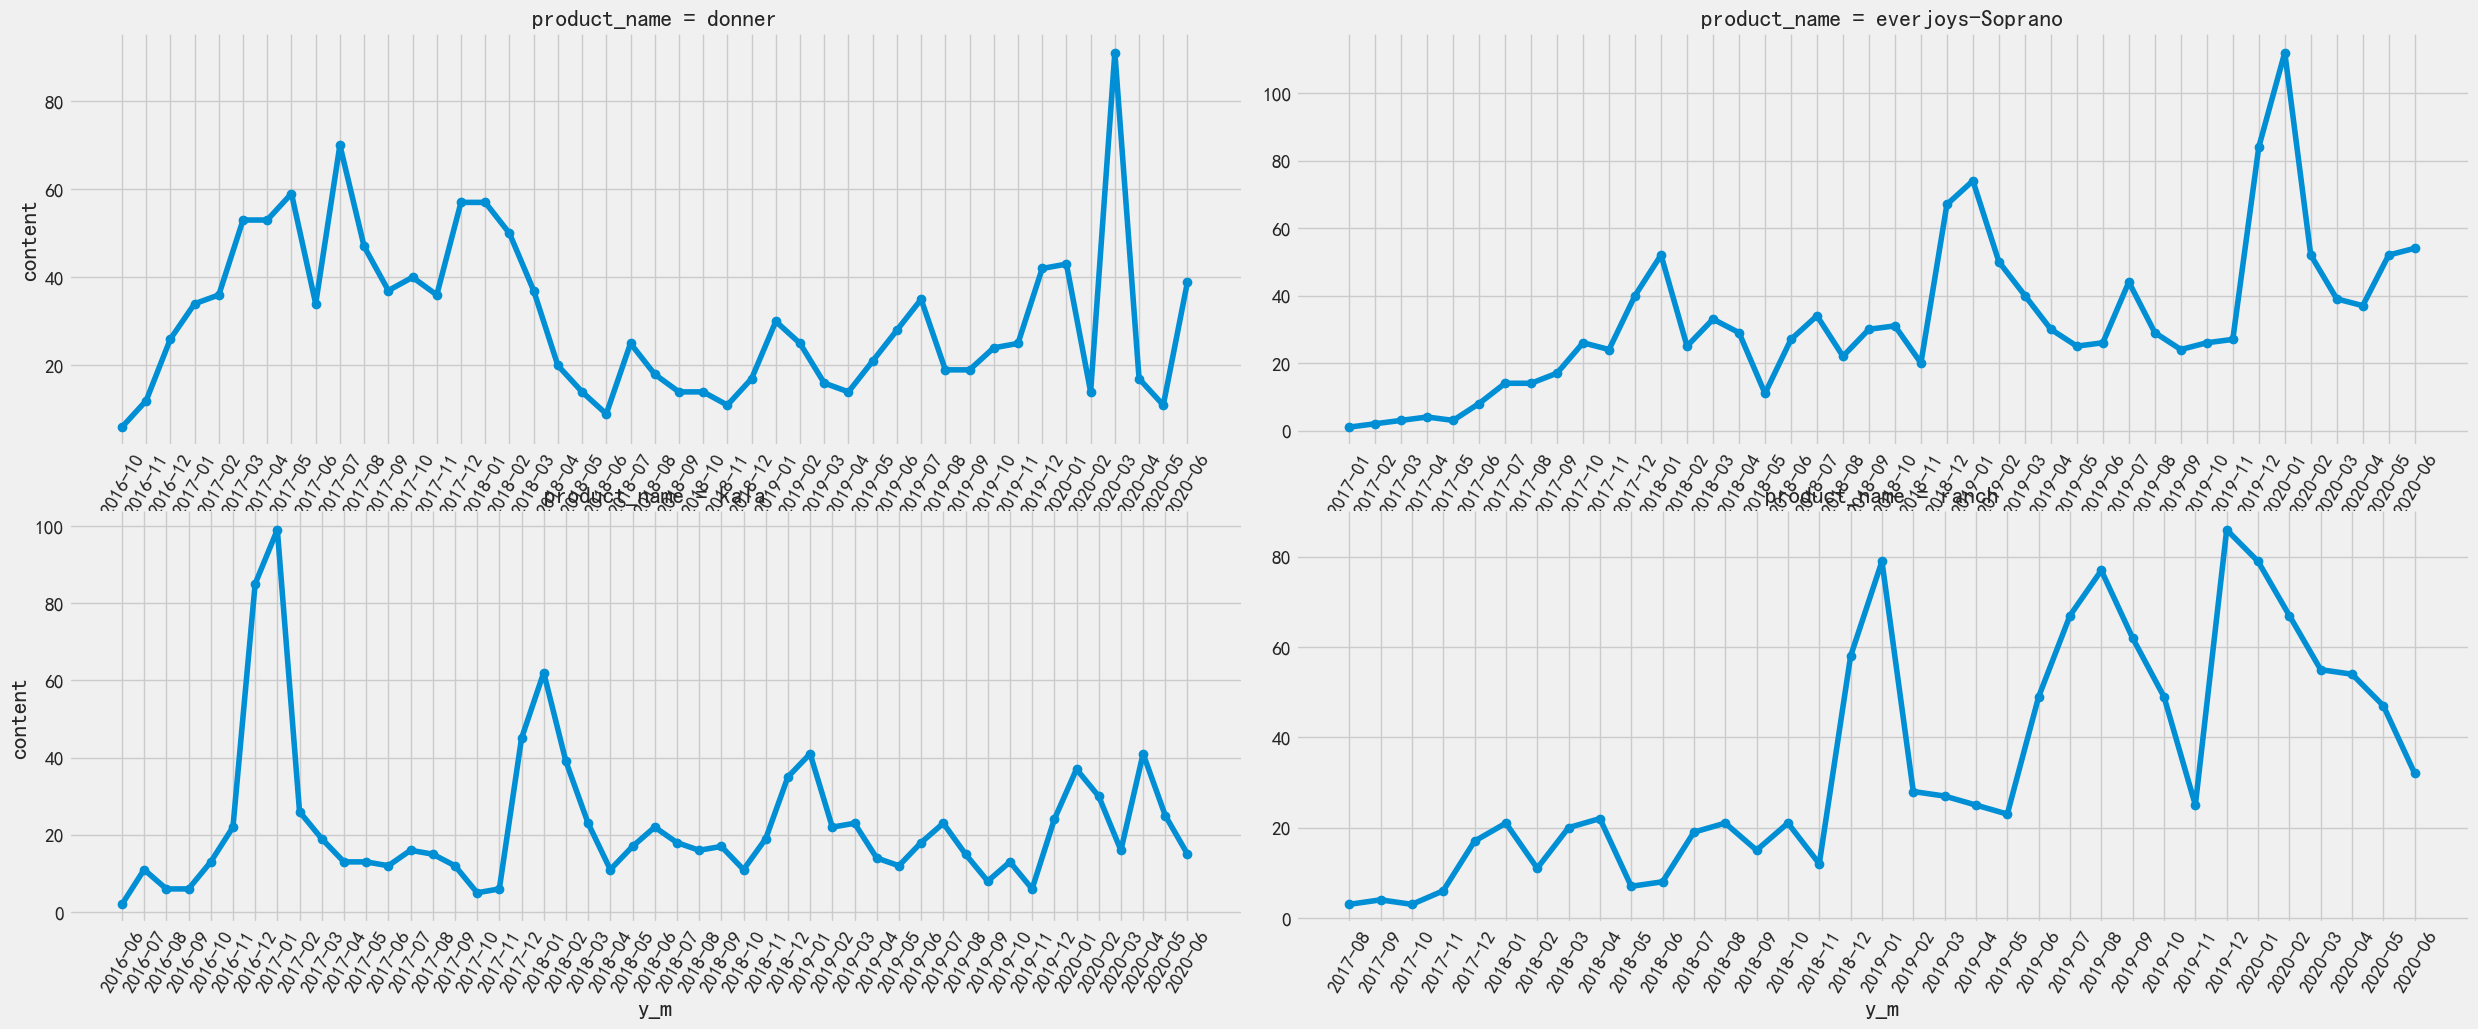

In [93]:
df_content = reviews_df.groupby(['product_name','y_m'])['content'].count().reset_index()
g = sns.FacetGrid(data=df_content,col='product_name',col_wrap=2,sharex=False,sharey=False,height=5,aspect=2.5)
g.map(plt.plot,'y_m','content',marker='o')
g.set_xticklabels(rotation=60)

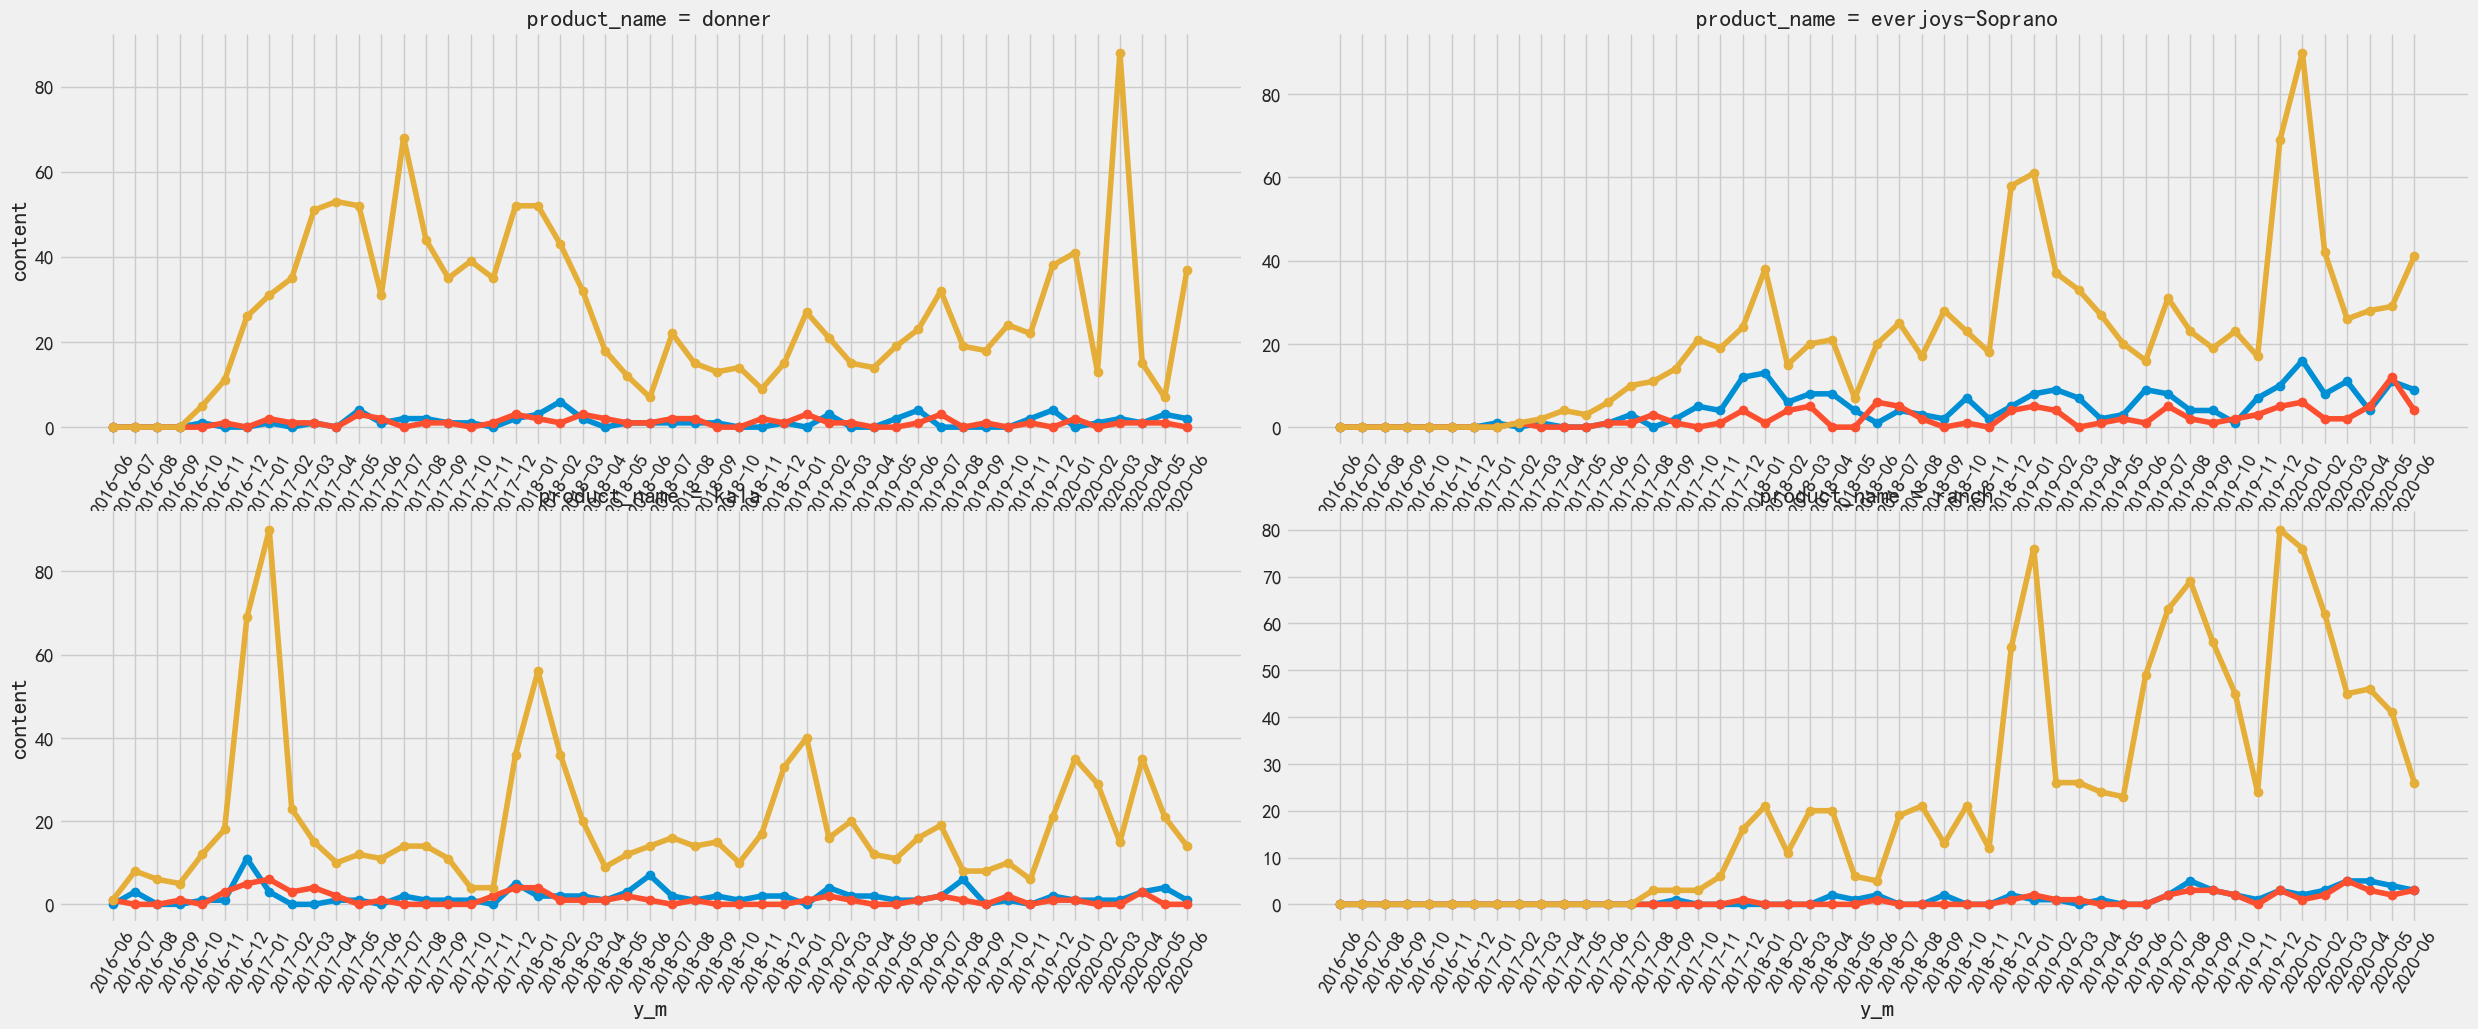

In [94]:
df_content = reviews_df.groupby(['product_name','y_m','reviews_cate'])['content'].count().reset_index()
g = sns.FacetGrid(data=df_content,col='product_name',hue='reviews_cate',col_wrap=2,sharex=False,sharey=False,height=5,aspect=2.5)
# marker 调整点的样式
g.map(plt.plot,'y_m','content',marker='o')
# x轴标签文字旋转一下,  rotation旋转
g.set_xticklabels(rotation=60)

In [95]:
df_content

,product_name,y_m,reviews_cate,content
0,donner,2016-06,差评,0
1,donner,2016-06,中评,0
2,donner,2016-06,好评,0
3,donner,2016-07,差评,0
4,donner,2016-07,中评,0
...,...,...,...,...
583,ranch,2020-05,中评,2
584,ranch,2020-05,好评,41
585,ranch,2020-06,差评,3
586,ranch,2020-06,中评,3


## 非结构化数据 词频统计

In [101]:
df_data =reviews_df.drop_duplicates(subset=['product_name','type','date','content'])

In [102]:
df_data.product_name.unique()

array(['everjoys-Soprano', 'ranch', 'kala', 'donner'], dtype=object)

In [105]:
sample_pos = df_data[(df_data['product_name']=='everjoys-Soprano') & (df_data['reviews_cate']=='好评')]
sample_neg = df_data[(df_data['product_name']=='everjoys-Soprano') & (df_data['reviews_cate']=='差评')]

In [106]:
sample_pos.shape

(1037, 10)

In [107]:
sample_neg.shape

(223, 10)

In [113]:
reviews_str = sample_neg['content'][4]
reviews_str

"It is a cute little ukulele, but is poor quality. The strings are very cheap plastic strings. Every time I finished tuning it, it would slip right back out of tune. I couldn't play it at all because it did not just slip out of tune a little, it was a huge difference that sounded very horrible and obvious. I HIGHLY recommend just spending a little extra money to buy a quality ukulele."

In [123]:
# 分词 把文本拆成一个一个的单词
import nltk
# 分词
tokens = nltk.word_tokenize(reviews_str)

In [124]:
tokens

['It',
 'is',
 'a',
 'cute',
 'little',
 'ukulele',
 ',',
 'but',
 'is',
 'poor',
 'quality',
 '.',
 'The',
 'strings',
 'are',
 'very',
 'cheap',
 'plastic',
 'strings',
 '.',
 'Every',
 'time',
 'I',
 'finished',
 'tuning',
 'it',
 ',',
 'it',
 'would',
 'slip',
 'right',
 'back',
 'out',
 'of',
 'tune',
 '.',
 'I',
 'could',
 "n't",
 'play',
 'it',
 'at',
 'all',
 'because',
 'it',
 'did',
 'not',
 'just',
 'slip',
 'out',
 'of',
 'tune',
 'a',
 'little',
 ',',
 'it',
 'was',
 'a',
 'huge',
 'difference',
 'that',
 'sounded',
 'very',
 'horrible',
 'and',
 'obvious',
 '.',
 'I',
 'HIGHLY',
 'recommend',
 'just',
 'spending',
 'a',
 'little',
 'extra',
 'money',
 'to',
 'buy',
 'a',
 'quality',
 'ukulele',
 '.']

In [127]:
# 词形还原
from nltk.corpus import wordnet as wn
def get_lemma(word):
    result = wn.morphy(word)
    if result is None:
        return word
    else:
        return result

tokens = [get_lemma(token) for token in tokens]

In [133]:
# 去停用词  运行下面的代码, 第一次执行会报错, 可以把资料中的data目录里的nltk_data.zip 解压缩到 C:/nltk_data  D:/nltk_data E:/nltk_data
# 其它可以放的路径, 可以参考报错信息
punctuation = [",", ":", ";", ".", "!", "'", '"', "’", "?", "/", "-", "+", "&", "(", ")","The","n't","could"]
stop_words = nltk.corpus.stopwords.words('english')+punctuation
tokens = [i for i in tokens if i not in stop_words]

In [134]:
tokens

['cute',
 'little',
 'ukulele',
 'poor',
 'quality',
 'strings',
 'cheap',
 'plastic',
 'strings',
 'Every',
 'time',
 'finish',
 'tuning',
 'would',
 'slip',
 'right',
 'back',
 'tune',
 'play',
 'slip',
 'tune',
 'little',
 'huge',
 'difference',
 'sound',
 'horrible',
 'obvious',
 'HIGHLY',
 'recommend',
 'spending',
 'little',
 'extra',
 'money',
 'buy',
 'quality',
 'ukulele']

In [140]:
from nltk.corpus import wordnet as wn
import nltk
# 词形还原的方法
def get_lemma(word):
    # 有些时候这个方法没有返回
    result = wn.morphy(word)
    # 没用返回的使用原来的文本
    if result is None:
        return word
    else:
        return result
#标点符号
punctuation = [",", ":", ";", ".", "!", "'", '"', "’", "?", "/", "-", "+", "&", "(", ")","The","n't","could"]
# 从nltk的安装目录下加载停用词表
stop_words = nltk.corpus.stopwords.words('english')+punctuation
## 把前面的流程整合起来
def prepare_text(sentence):
    # 传入一句话, 先走英文分词
    tokens = nltk.word_tokenize(sentence)
    # 走词形还原
    tokens = [get_lemma(token) for token in tokens]
    # 去停用词
    tokens = [i for i in tokens if i not in stop_words]
    return tokens

In [143]:
pos_text_result = sample_pos['content'].apply(prepare_text).to_list()
neg_text_result = sample_neg['content'].apply(prepare_text).to_list()

In [144]:
len(neg_text_result)

223

In [145]:
len(pos_text_result)

1037

In [146]:
pos_text_result[0]

['Very',
 'nice',
 'product',
 'ukulele',
 'light',
 'craftsmanship',
 'great',
 'Everything',
 'come',
 'good',
 'well',
 'Needs',
 'lots',
 'tuning',
 'beginning']

In [161]:
from collections import Counter
# 统计词频
def get_words(text):
    words_all = []
    # 从 二维列表中, 遍历所有的单词, 放到同一个一维列表中
    # text 是所有的好评/差评
    for words in text:
        for word in words:
            words_all.append(word)
    # 通过Counter来统计词频
    word_freq = Counter(words_all)
    # 所有的文本进行去重
    total_words = list(set(words_all))
    #平均每条评论有多少词 len(words_all) 这些评论中一共有多少个词  len(text) 一共有多少条评论
    content_mean = len(words_all)/len(text)
    # 去重之后的文本数量/没有去重的文本数量
    words_cap =len(total_words)/len(words_all)
    return word_freq,content_mean,words_cap

word_freq_neg,content_mean,words_cap = get_words(neg_text_result)
neg_words_wordcloud = word_freq_neg.most_common(100)

In [151]:
content_mean

20.46188340807175

In [152]:
words_cap

0.26977865439403903

In [157]:
word_freq,content_mean,words_cap = get_words(pos_text_result)
positive_words_wordcloud =word_freq.most_common(100)

In [158]:
positive_words_wordcloud

[('love', 347),
 ('ukulele', 308),
 ('great', 260),
 ('play', 231),
 ('tune', 212),
 ('good', 199),
 ('get', 187),
 ('tuner', 184),
 ('beginner', 184),
 ('come', 179),
 ('daughter', 169),
 ("'s", 156),
 ('one', 155),
 ('quality', 153),
 ('learn', 153),
 ('strings', 149),
 ('instrument', 147),
 ('sound', 145),
 ('like', 137),
 ('This', 133),
 ('price', 128),
 ('well', 122),
 ('buy', 116),
 ('easy', 112),
 ('Great', 112),
 ('little', 108),
 ('make', 101),
 ('gift', 101),
 ('really', 100),
 ('old', 97),
 ('want', 96),
 ('need', 95),
 ('ha', 94),
 ('She', 93),
 ('nice', 92),
 ('use', 88),
 ('Ukulele', 86),
 ('son', 82),
 ('would', 81),
 ('playing', 80),
 ('product', 79),
 ('start', 78),
 ('purchase', 74),
 ('first', 74),
 ('year', 73),
 ('everything', 73),
 ('uke', 72),
 ('tuning', 68),
 ('time', 68),
 ('learning', 67),
 ('case', 66),
 ('much', 63),
 ('recommend', 62),
 ('perfect', 61),
 ('look', 58),
 ('happy', 54),
 ('Christmas', 54),
 ('Good', 52),
 ('color', 52),
 ('song', 52),
 ('beau

In [154]:
content_mean

16.07039537126326

In [155]:
words_cap

0.14563456345634562

In [ ]:
# 绘制词云图

In [160]:
from pyecharts.charts import WordCloud
import pyecharts.options as opts
(WordCloud().add(series_name="好评词云",
                 data_pair=positive_words_wordcloud, #传入绘制词云图的数据
                 word_size_range=[16, 80]) #word_size_range字号大小取值范围
    .set_global_opts(title_opts=opts.TitleOpts(
        title="好评词云", 
        title_textstyle_opts=opts.TextStyleOpts(font_size=23) # 设置标题字号
 ),
tooltip_opts=opts.TooltipOpts(is_show=True),# 设置为True 鼠标滑过文字会弹出提示框
            ).
 render()
)

'C:\\Develop\\深圳42\\day07\\02_代码\\render.html'

In [165]:
(WordCloud().add(series_name="差评文本",
                 data_pair=neg_words_wordcloud, #传入绘制词云图的数据
                 word_size_range=[16, 80]) #word_size_range字号大小取值范围
    .set_global_opts(title_opts=opts.TitleOpts(
        title="差评词云图", 
        title_textstyle_opts=opts.TextStyleOpts(font_size=23) # 设置标题字号
 ),
tooltip_opts=opts.TooltipOpts(is_show=True),# 设置为True 鼠标滑过文字会弹出提示框
            ).
 render('neg_wordcloud.html')
)

'C:\\Develop\\深圳42\\day07\\02_代码\\neg_wordcloud.html'